In [2]:
import importlib

required_packages = [
    'torch',
    'pandas',
    'sklearn',
    'IPython',
    'numpy'
]

missing = []

print("🔍 Checking required packages...\n")

for pkg in required_packages:
    try:
        importlib.import_module(pkg)
        print(f"✅ {pkg} is installed.")
    except ImportError:
        print(f"❌ {pkg} is NOT installed.")
        missing.append(pkg)

if missing:
    print("\n📦 You can install missing packages with:")
    print(f"!pip install {' '.join(missing)}")
else:
    print("\n🎉 All required packages are installed!")


🔍 Checking required packages...

✅ torch is installed.
✅ pandas is installed.
✅ sklearn is installed.
✅ IPython is installed.
✅ numpy is installed.

🎉 All required packages are installed!


In [3]:
import torch, pandas, numpy, sklearn, IPython

print("Torch:", torch.__version__)
print("Pandas:", pandas.__version__)
print("Numpy:", numpy.__version__)
print("Sklearn:", sklearn.__version__)
print("IPython:", IPython.__version__)


Torch: 2.6.0
Pandas: 2.2.2
Numpy: 1.26.4
Sklearn: 1.6.1
IPython: 8.27.0


In [4]:
import sys
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from IPython.display import display
sys.path.append('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/scripts/ncf-utils')
from utils import Utils, EarlyStopping, cols_dict
from model import NCF

sys.path.append('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/scripts/ncf-utils')
pd.set_option("display.max_columns", 6)
import os
os.makedirs("weights", exist_ok=True)


In [5]:
print("🔹 Loading data...")
ratings_data = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/ratings.dat', sep='::', names=cols_dict['ratings'], engine='python')
users_data = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/users.dat', sep='::', names=cols_dict['users'], engine='python')
items_data = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/movies.dat', sep='::', names=cols_dict['items'], encoding='latin-1', engine='python')

print("✅ Data loaded.")
print("Ratings data (3 rows):")
display(ratings_data.head(3))

print("Users data (3 rows):")
display(users_data.head(3))

print("Items data (3 rows):")
display(items_data.head(3))

print("Ratings shape:", ratings_data.shape)
print("Users shape:", users_data.shape)
print("Items shape:", items_data.shape)


🔹 Loading data...
✅ Data loaded.
Ratings data (3 rows):


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


Users data (3 rows):


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117


Items data (3 rows):


,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


Ratings shape: (1000209, 4)
Users shape: (6040, 5)
Items shape: (3883, 3)


In [6]:
# --- BACKUP ORIGINAL DATA ---
users_data_og = users_data.copy()
items_data_og = items_data.copy()
ratings_data_og = ratings_data.copy()

In [7]:
print("🔎 Checking for missing values...")
print("Ratings nulls:", ratings_data.isnull().sum().sum())
print("Users nulls:", users_data.isnull().sum().sum())
print("Items nulls:", items_data.isnull().sum().sum())


🔎 Checking for missing values...
Ratings nulls: 0
Users nulls: 0
Items nulls: 0


In [8]:

# One-hot encode gender and occupation for users
print("🔹 One-hot encoding users' gender and occupation...")
users_data = Utils.one_hot_encode(users_data, ['occupation', 'gender', 'age'])

# Multi-hot encode genres for items
print("🔹 Multi-hot encoding items' genres...")
items_data = Utils.multi_hot_encode(items_data, 'genre')

# Display a sample of transformed data
print("Users data after encoding:")
display(users_data.head(3))

print("Items data after encoding:")
display(items_data.head(3))


🔹 One-hot encoding users' gender and occupation...
🔹 Multi-hot encoding items' genres...
Users data after encoding:


,user_id,zip_code,occupation_0,...,age_45,age_50,age_56
0,1,48067,0,...,0,0,0
1,2,70072,0,...,0,0,1
2,3,55117,0,...,0,0,0


Items data after encoding:


,movie_id,title,Action,...,Thriller,War,Western
0,1,Toy Story (1995),0,...,0,0,0
1,2,Jumanji (1995),0,...,0,0,0
2,3,Grumpier Old Men (1995),0,...,0,0,0


In [9]:
users_data = Utils.extract_category_avg_ratings(users_data, items_data, ratings_data)
items_data = Utils.extract_year(items_data)


In [10]:
users_data = Utils.move_column(users_data, ['gender_M', 'gender_F'], 0)

In [11]:
# --- ALIGN USERS & ITEMS ---
users_data, items_data = Utils.extend_users_items(users_data, items_data, ratings_data)

In [12]:
# --- DROP UNUSED COLUMNS ---
ratings_data = ratings_data.drop(['timestamp'], axis=1)
users_data = users_data.drop(['user_id', 'zip_code'], axis=1)
items_data = items_data.drop(['movie_id', 'title'], axis=1)

In [13]:
# --- NORMALIZATION ---
ratings_data['rating'] = ratings_data['rating'] / 5.0
items_data['year'] = items_data['year'] / items_data['year'].max()
users_data.iloc[:, -18:] = users_data.iloc[:, -18:] / users_data.iloc[:, -18:].max().max()

# --- SPLIT DATA ---
X_users_train, X_users_test = train_test_split(users_data, test_size=0.2, random_state=42)
X_users_val, X_users_test = train_test_split(X_users_test, test_size=0.5, random_state=42)

X_items_train, X_items_test = train_test_split(items_data, test_size=0.2, random_state=42)
X_items_val, X_items_test = train_test_split(X_items_test, test_size=0.5, random_state=42)

y_ratings_train, y_ratings_test = train_test_split(ratings_data, test_size=0.2, random_state=42)
y_ratings_val, y_ratings_test = train_test_split(y_ratings_test, test_size=0.5, random_state=42)

# --- CONVERT TO NUMPY ---
X_users_train, X_users_val, X_users_test = X_users_train.values, X_users_val.values, X_users_test.values
X_items_train, X_items_val, X_items_test = X_items_train.values, X_items_val.values, X_items_test.values
y_ratings_train, y_ratings_val, y_ratings_test = y_ratings_train.values, y_ratings_val.values, y_ratings_test.values

In [14]:
print("X_items_test:")
print(X_items_test)

print("\nX_items_train:")
print(X_items_train)

print("\nX_items_val:")
print(X_items_val)

print("\nX_users_test:")
print(X_users_test)

print("\nX_users_train:")
print(X_users_train)

print("\nX_users_val:")
print(X_users_val)

print("\ncols_dict:")
print(cols_dict)

print("\ndir:")
print(dir)

print("\nitems_data:")
print(items_data)

print("\nratings_data:")
print(ratings_data)

print("\nusers_data:")
print(users_data)

print("\ny_ratings_test:")
print(y_ratings_test)

print("\ny_ratings_train:")
print(y_ratings_train)

print("\ny_ratings_val:")
print(y_ratings_val)

X_items_test:
[[0.     0.     0.     ... 0.     0.     0.996 ]
 [0.     0.     0.     ... 0.     0.     0.9995]
 [0.     0.     0.     ... 0.     1.     0.9825]
 ...
 [1.     1.     0.     ... 0.     0.     0.9935]
 [0.     0.     0.     ... 0.     0.     0.9985]
 [0.     0.     0.     ... 0.     0.     0.993 ]]

X_items_train:
[[0.     0.     0.     ... 1.     0.     0.9775]
 [0.     0.     0.     ... 0.     0.     0.9995]
 [1.     0.     0.     ... 0.     0.     0.9965]
 ...
 [0.     0.     0.     ... 0.     0.     0.9925]
 [0.     1.     0.     ... 0.     0.     0.9925]
 [1.     0.     0.     ... 1.     0.     0.998 ]]

X_items_val:
[[0.     0.     0.     ... 0.     0.     0.9915]
 [0.     0.     0.     ... 0.     0.     0.9975]
 [0.     1.     0.     ... 0.     0.     0.9885]
 ...
 [0.     0.     0.     ... 0.     0.     0.9955]
 [1.     0.     0.     ... 0.     0.     0.9895]
 [0.     0.     0.     ... 0.     0.     0.996 ]]

X_users_test:
[[1.         0.         1.         ... 0.

In [15]:
# --- MODEL SETUP ---
user_dim = users_data.shape[1]
item_dim = items_data.shape[1]
num_users = users_data_og['user_id'].max()
num_items = items_data_og['movie_id'].max()

model = NCF(
    num_users=num_users,
    num_items=num_items,
    user_dim=user_dim,
    item_dim=item_dim,
    num_factors=32,
    mode='explicit',
    criterion=torch.nn.MSELoss(),
    dropout=0.1,
    lr=1e-3,
    weight_decay=1e-5,
    verbose=True,
    gpu=True
)

NCF(
  (user_embedding_mlp): Embedding(6041, 32)
  (item_embedding_mlp): Embedding(3953, 32)
  (user_embedding_mf): Embedding(6041, 32)
  (item_embedding_mf): Embedding(3953, 32)
  (user_features): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (item_features): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (MLP): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=32, bias=True)
    (10): ReLU

Epoch 1/12
391/391 - loss: 0.0353 - Val Loss: 0.0325 - R2: 0.3529 - MAE: 0.1427 - MSE: 0.0325 - RMSE: 0.1803 - lr: 0.001
Epoch 2/12
391/391 - loss: 0.0318 - Val Loss: 0.0312 - R2: 0.3784 - MAE: 0.1396 - MSE: 0.0312 - RMSE: 0.1767 - lr: 0.001
Epoch 3/12
391/391 - loss: 0.0303 - Val Loss: 0.0303 - R2: 0.3962 - MAE: 0.1373 - MSE: 0.0303 - RMSE: 0.1742 - lr: 0.001
Epoch 4/12
391/391 - loss: 0.0293 - Val Loss: 0.0300 - R2: 0.4032 - MAE: 0.1366 - MSE: 0.0300 - RMSE: 0.1731 - lr: 0.001
Epoch 5/12
391/391 - loss: 0.0287 - Val Loss: 0.0297 - R2: 0.4094 - MAE: 0.1364 - MSE: 0.0297 - RMSE: 0.1722 - lr: 0.001
Epoch 6/12
391/391 - loss: 0.0281 - Val Loss: 0.0294 - R2: 0.4138 - MAE: 0.1354 - MSE: 0.0294 - RMSE: 0.1716 - lr: 0.001
Epoch 7/12
391/391 - loss: 0.0277 - Val Loss: 0.0292 - R2: 0.4182 - MAE: 0.1346 - MSE: 0.0292 - RMSE: 0.1709 - lr: 0.001
Epoch 8/12
391/391 - loss: 0.0273 - Val Loss: 0.0292 - R2: 0.4178 - MAE: 0.1344 - MSE: 0.0292 - RMSE: 0.1710 - lr: 0.0001
Epoch 9/12
391/391 - loss: 0.02

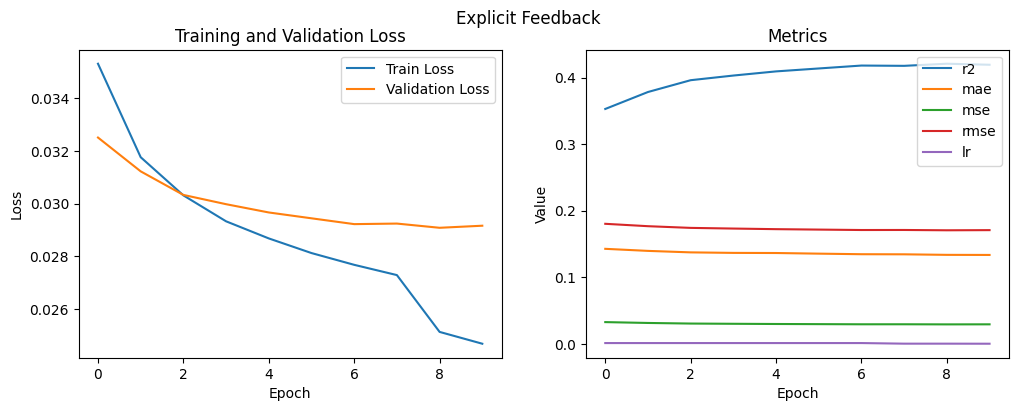

In [16]:
early_stopping = EarlyStopping(patience=3, delta=0.0002, path='weights/explicit.pth')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(model.optimizer, mode='min', factor=0.1, patience=0)

history = model.fit(
    X=[y_ratings_train[:, 0], y_ratings_train[:, 1], X_users_train, X_items_train],
    y=y_ratings_train[:, 2],
    X_val=[y_ratings_val[:, 0], y_ratings_val[:, 1], X_users_val, X_items_val],
    y_val=y_ratings_val[:, 2],
    epochs=12,
    batch_size=2048,
    early_stopping=early_stopping,
    scheduler=scheduler
)

Utils.plot_metrics(history, 'Explicit Feedback')

In [17]:
# --- Step 6: Model Evaluation ---
print("🔹 Evaluating model on test data...")

model.eval() # Set model to evaluation mode (disables dropout layers)

avg_loss, r2, mae, mse, rmse = model.evaluate(
    [y_ratings_test[:, 0], y_ratings_test[:, 1], X_users_test, X_items_test],
    y_ratings_test[:, 2],
    batch_size=256
)

print(f"Average Loss: {avg_loss:.4f}, R2: {r2:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")


🔹 Evaluating model on test data...
Average Loss: 0.0293, R2: 0.4142, MAE: 0.1338, MSE: 0.0293, RMSE: 0.1713


In [20]:
new_user = {
    'id': 7000, # new user id
    'age': 20,
    'occupation': 'engineer',
    'gender': 'F',
    'genres': ['Children', 'Comedy', 'Animation'],
}

user_id, user, weights, _ = Utils.preprocess_user(
                                user=new_user,
                                num_items=items_data_og.shape[0],
                                users=users_data.drop_duplicates(inplace=False).values,
                                weights=[model.user_embedding_mlp.weight.data.cpu().numpy(), model.user_embedding_mf.weight.data.cpu().numpy()]
                                )
items = Utils.preprocess_items(items_data_og)

user_id, user = user_id.to(model.device), user.to(model.device)

In [21]:
# 1- Retrieval Stage
movies = Utils.retrieve(
    movies=items,
    user=user.detach().cpu().numpy(),
    num_genres=3,
    k=300, # retrieve 300 relevant movies. Note: higher k leads to better recommendations but slower inference
    random_state=0
)

# 2- Filtering Stage
movie_ids, movies = Utils.filter( # Removes already-rated / duplicate movies
    movies=movies,
    ratings=ratings_data_og,
    user_id=new_user['id']
)
movie_ids, movies = movie_ids.to(model.device), movies.to(model.device)

# 3- Ranking Stage
y_pred = model(
    user_id[:len(movies)],
    movie_ids,
    user[:len(movies)],
    movies,
    weights
).cpu().detach().numpy()

# 4- Ordering Stage
movies_retrieved = items_data_og[items_data_og['movie_id'].isin(movie_ids.cpu().numpy())].sort_values(by='movie_id', key=lambda x: pd.Categorical(x, categories=movie_ids.cpu().numpy(), ordered=True))
Utils.order(y_pred, movies_retrieved, 'explicit', top_k=10)

,movie_id,title,genre,predicted_rating
0,1148,"Wrong Trousers, The (1993)",Animation|Comedy,4.51
1,720,Wallace & Gromit: The Best of Aardman Animatio...,Animation,4.45
2,3114,Toy Story 2 (1999),Animation|Children's|Comedy,4.32
3,1,Toy Story (1995),Animation|Children's|Comedy,4.24
4,3396,"Muppet Movie, The (1979)",Children's|Comedy,4.22
5,1136,Monty Python and the Holy Grail (1974),Comedy,4.20
6,3429,Creature Comforts (1990),Animation|Comedy,4.18
7,1223,"Grand Day Out, A (1992)",Animation|Comedy,4.14
8,3397,"Great Muppet Caper, The (1981)",Children's|Comedy,4.05
9,2081,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance,4.04


In [22]:
old_user = {
    'id': 400
}

# preprocess the old user
user_id, user, _, _ = Utils.preprocess_user(
                                user=old_user,
                                num_items=items_data_og.shape[0],
                                users=users_data.drop_duplicates(inplace=False).values,
                                topk=3, # top 3 genres the user has interacted with. MAX: 18
                                verbose=True
                                )
items = Utils.preprocess_items(items_data_og)

user_id, user = user_id.to(model.device), user.to(model.device)


User id: 400 top 3 genres: ['Thriller' 'Action' 'Adventure']


In [23]:
# 1- Retrieval Stage
movies = Utils.retrieve(
    movies=items,
    user=user.detach().cpu().numpy(),
    k=300, # retrieve 300 relevant movies. Note: higher k leads to better recommendations but slower inference
    random_state=0
)

# 2- Filtering Stage
movie_ids, movies = Utils.filter( # Removes already-rated / duplicate movies
    movies=movies,
    ratings=ratings_data_og,
    user_id=new_user['id']
)
movie_ids, movies = movie_ids.to(model.device), movies.to(model.device)

# 3- Ranking Stage
y_pred = model(
    user_id[:len(movies)],
    movie_ids,
    user[:len(movies)],
    movies
).cpu().detach().numpy()

# 4- Ordering Stage
movies_retrieved = items_data_og[items_data_og['movie_id'].isin(movie_ids.cpu().numpy())].sort_values(by='movie_id', key=lambda x: pd.Categorical(x, categories=movie_ids.cpu().numpy(), ordered=True))
Utils.order(y_pred, movies_retrieved, 'eplicit', top_k=10)

,movie_id,title,genre,predicted_score
0,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.39
1,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Romance,4.25
2,1479,"Saint, The (1997)",Action|Romance|Thriller,4.21
3,110,Braveheart (1995),Action|Drama|War,4.20
4,733,"Rock, The (1996)",Action|Adventure|Thriller,4.19
5,2273,Rush Hour (1998),Action|Thriller,4.12
6,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.10
7,2161,"NeverEnding Story, The (1984)",Adventure|Children's|Fantasy,4.08
8,1620,Kiss the Girls (1997),Crime|Drama|Thriller,4.07
9,180,Mallrats (1995),Comedy,4.06
